In [ ]:
# ============================================================
# NOTEBOOK 05 — EXPLANATORY ANALYSIS
# ============================================================
# PURPOSE:
# Notebook 04 showed pre-game features can't predict match
# outcomes (~50%, by design of matchmaking + incomplete team data).
#
# This notebook answers a DIFFERENT, descriptive question:
#   "Which IN-GAME behaviors most distinguish winning from
#    losing performances?"
#
# IMPORTANT FRAMING:
# This is EXPLANATORY, not predictive. We use in-game stats
# (the actual match's KDA, gold, vision etc.) to SEE what
# winning looks like — NOT to forecast the future. Using
# in-game stats to "predict" the same game would be circular;
# using them to DESCRIBE what separates wins from losses is
# a legitimate, standard analytical technique.
#
# Output: SHAP-ranked behavioral drivers of winning, which
# feed the business recommendations in Part 05.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import xgboost as xgb
import shap

# We load the ORIGINAL in-game features this time (not historical)
# df_model.csv was saved at the end of notebook 02's first version
# — it has the per-match in-game stats
df = pd.read_csv('df_model.csv')

print("Loaded:", df.shape)
print("Columns:", df.columns.tolist())
print("\nWin rate:", round(df['Win'].mean(), 3))

Loaded: (433537, 12)
Columns: ['Win', 'kda_ratio', 'gold_per_min', 'dmg_per_min', 'cs_per_min', 'visionScore', 'objective_participation', 'Lane', 'RankName', 'GameDuration', 'SummonerFk', 'MatchFk']

Win rate: 0.501


In [ ]:
# ============================================================
# CELL 2 — PREPARE FEATURES (in-game behavioral)
# Explanatory model: use the ACTUAL match's behavioral stats
# to describe what separates wins from losses.
# We one-hot encode Lane (keep all categories visible).
# ============================================================

# Drop UNKNOWN lane rows — not a real role
df = df[df['Lane'] != 'UNKNOWN'].copy()
print("Rows after dropping UNKNOWN lane:", len(df))

# In-game behavioral features (the actual match values)
behavioral_features = ['kda_ratio', 'gold_per_min', 'dmg_per_min',
                       'cs_per_min', 'visionScore', 'objective_participation']

# One-hot encode Lane, all categories visible
df_encoded = pd.get_dummies(df, columns=['Lane'], drop_first=False)
lane_cols = [c for c in df_encoded.columns if c.startswith('Lane_')]

# Final feature set
model_features = behavioral_features + lane_cols
print("Features used:", model_features)

Rows after dropping UNKNOWN lane: 413900
Features used: ['kda_ratio', 'gold_per_min', 'dmg_per_min', 'cs_per_min', 'visionScore', 'objective_participation', 'Lane_BOTTOM', 'Lane_JUNGLE', 'Lane_MIDDLE', 'Lane_TOP', 'Lane_UTILITY']


In [ ]:
# ============================================================
# CELL 3 — TRAIN/TEST SPLIT + SCALING
# Logistic regression needs scaled features (it's sensitive to
# feature ranges). XGBoost doesn't care, but we scale once and
# use the scaled version for LogReg, raw for XGBoost.
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X = df_encoded[model_features]
y = df_encoded['Win']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (331120, 11) Test: (82780, 11)


In [ ]:
# ============================================================
# CELL 4 — LOGISTIC REGRESSION (interpretable baseline)
# A simple linear model. Each coefficient shows how a feature
# shifts win odds. We use this as our baseline to compare
# XGBoost against.
# ============================================================
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)

logreg_pred = logreg.predict(X_test_scaled)
logreg_proba = logreg.predict_proba(X_test_scaled)[:, 1]

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, logreg_pred, target_names=['Loss', 'Win']))
print("AUC-ROC:", round(roc_auc_score(y_test, logreg_proba), 3))

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

        Loss       0.76      0.84      0.80     41328
         Win       0.82      0.74      0.78     41452

    accuracy                           0.79     82780
   macro avg       0.79      0.79      0.79     82780
weighted avg       0.79      0.79      0.79     82780

AUC-ROC: 0.873


In [ ]:
# ============================================================
# CELL 5 — XGBOOST (captures non-linear effects & interactions)
# We compare its performance to the logistic baseline. A
# meaningful gain suggests non-linear behavioral patterns.
# ============================================================
model = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    random_state=42, eval_metric='logloss'
)
model.fit(X_train, y_train)

xgb_pred = model.predict(X_test)
xgb_proba = model.predict_proba(X_test)[:, 1]

print("=== XGBOOST ===")
print(classification_report(y_test, xgb_pred, target_names=['Loss', 'Win']))
print("AUC-ROC:", round(roc_auc_score(y_test, xgb_proba), 3))

=== XGBOOST ===
              precision    recall  f1-score   support

        Loss       0.80      0.80      0.80     41328
         Win       0.80      0.80      0.80     41452

    accuracy                           0.80     82780
   macro avg       0.80      0.80      0.80     82780
weighted avg       0.80      0.80      0.80     82780

AUC-ROC: 0.884


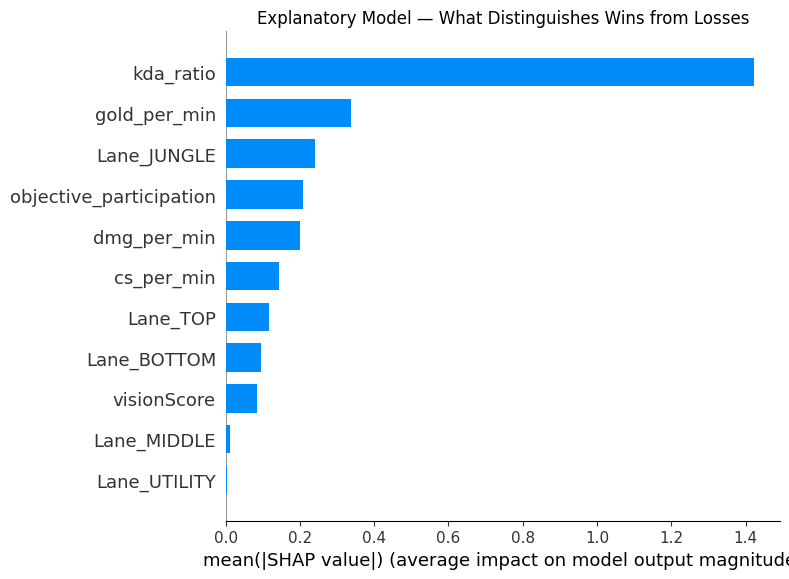

In [ ]:
# ============================================================
# CELL 6 — SHAP ON XGBOOST (the explanatory payoff)
# Now that the model has real signal (80%/0.884), SHAP will
# show meaningful feature contributions — which in-game
# behaviors most distinguish wins from losses.
# ============================================================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Bar plot — overall importance
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('Explanatory Model — What Distinguishes Wins from Losses')
plt.tight_layout()
plt.savefig('shap_explanatory_importance.png', dpi=150, bbox_inches='tight')
plt.show()

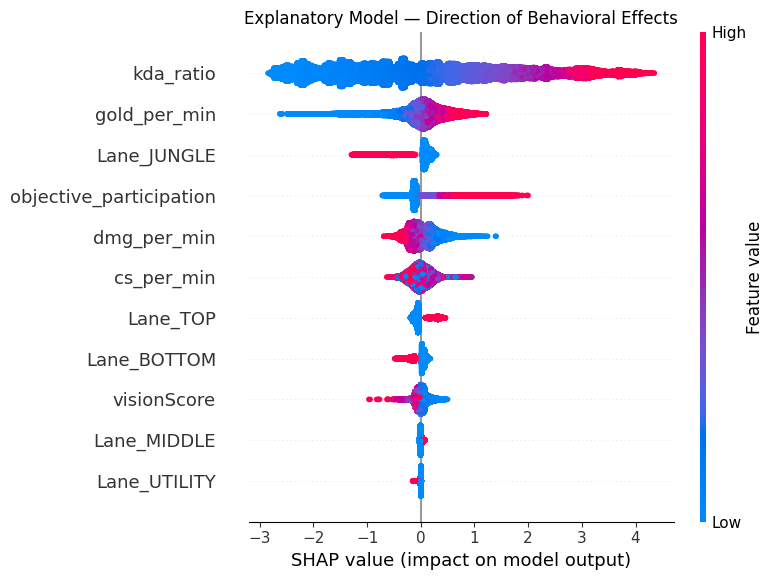

In [ ]:
# ============================================================
# CELL 7 — SHAP BEESWARM (direction of effects)
# The bar chart shows IMPORTANCE. The beeswarm shows DIRECTION:
# red = high feature value, blue = low.
# If high kda_ratio (red) sits on the positive side, it means
# high KDA pushes toward winning — confirming the relationship.
# ============================================================
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Explanatory Model — Direction of Behavioral Effects')
plt.tight_layout()
plt.savefig('shap_explanatory_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## Notebook 05 — Summary & Findings

### Purpose
Notebook 04 showed that pre-game features cannot predict match outcomes
(~50%, AUC 0.508). This notebook asks a different, **explanatory** question:
*"Which in-game behaviors most distinguish winning from losing performances?"*

This is descriptive, not predictive — we use the actual match's behavioral
stats to understand what winning looks like, not to forecast the future.

### Models compared
| Model | Accuracy | AUC-ROC |
|-------|----------|---------|
| Logistic Regression (baseline) | 79% | 0.873 |
| XGBoost | 80% | 0.884 |

The two models performed almost identically, suggesting the relationship
between behavior and winning is largely linear — there are no strong hidden
interactions. XGBoost's marginal edge implies minor non-linear effects.
The interpretable baseline captures most of the signal.

### Key behavioral drivers (SHAP)
1. **kda_ratio** — by far the dominant differentiator. Note: KDA is tightly
   coupled with winning by nature (low deaths ≈ winning team), so it is more
   a *signature* of a won game than an actionable lever.
2. **gold_per_min** — economic advantage strongly associates with winning.
3. **objective_participation** — securing dragons/barons pushes toward wins.
4. **Lane (Jungle)** — role carries measurable influence on outcome.
5. **visionScore** — surprisingly weak at the individual level, despite the
   community treating vision as critical. A counterintuitive, data-driven finding.

### The pre-game vs in-game contrast (the project's core insight)
| | Pre-game (NB 04) | In-game (NB 05) |
|--|------------------|-----------------|
| Accuracy | 50% | 80% |
| AUC | 0.508 | 0.884 |

Same dataset, same modeling approach — the only change is feature timing.
In-game behavior is strongly tied to winning (80%), but that behavior is
unknowable before the match. This is precisely why pre-game prediction
hits a wall, and why effective matchmaking needs team-level data.

### Actionable vs descriptive distinction
Not all "important" features are actionable. KDA largely *describes* a won
game; the more actionable levers for player improvement are gold efficiency,
objective control, and role-specific play. This distinction matters when
translating model output into coaching or design recommendations.

### Limitations
- Explanatory only — does not forecast, by design.
- Single-player rows — no team context (same constraint as Notebook 04).
- Champion excluded — kept the focus on behavioral signals.
- Findings reflect this patch/region sample and may shift with balance changes.